In [1]:
import sys
import os
import numpy as np
import datetime

import matplotlib.pyplot as plt

sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config
#%matplotlib notebook

In [2]:
lake = 'zug'
model = f'{lake}_100m_2025'
mitgcm_config, ds_to_plot = open_mitgcm_ds_from_config('..//config.json', model)

In [3]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "figures")
os.makedirs(output_folder, exist_ok=True)

In [4]:
plot_line = 15000

In [5]:
grid_resolution = 100
ds_to_plot['YC'] = np.arange(1, len(ds_to_plot['YC'])+1) * grid_resolution - grid_resolution/2
ds_to_plot['XC'] = np.arange(1, len(ds_to_plot['XC'])+1) * grid_resolution - grid_resolution/2
ds_to_plot['YG'] = np.arange(0, len(ds_to_plot['YG'])) * grid_resolution
ds_to_plot['XG'] = np.arange(0, len(ds_to_plot['XG'])) * grid_resolution

In [6]:
ds_to_plot['THETA'] = ds_to_plot['THETA'].where(ds_to_plot['THETA'] != 0, np.nan)

In [7]:
aligned_u = ds_to_plot.UVEL.rename({'XG':'XC'})
aligned_u['XC'] = ds_to_plot['XC']

aligned_v = ds_to_plot.VVEL.rename({'YG':'YC'})
aligned_v['YC'] = ds_to_plot['YC']

aligned_w = ds_to_plot.WVEL.rename({'Zl':'Z'})
aligned_w['Z'] = ds_to_plot['Z']

# Map

In [8]:
def plot_map(i_time: int, i_depth: int, scale_arrow, subsetting_factor_arrow, vmin=None, vmax=None):
    plt.ioff()
    plt.close()
    fig, ax = plt.subplots(figsize=(14,7))
    
    T_plot = ds_to_plot['time'].values[i_time]
    Z_plot = ds_to_plot['Z'].values[i_depth]
    xr_plot = ds_to_plot['THETA'].sel(time=T_plot, Z=Z_plot)
    xr_plot = xr_plot.where(xr_plot != 0, np.nan)
    if vmin and vmax:
        xr_plot.plot(cmap='jet', vmin=vmin, vmax=vmax)
    else:
        xr_plot.plot(cmap='jet')
    plt.axis('equal')

    subsetting_factor = subsetting_factor_arrow
    X_trimmed = ds_to_plot['XC'][::subsetting_factor]
    Y_trimmed = ds_to_plot['YC'][::subsetting_factor]
    U_trimmed = ds_to_plot['UVEL'].sel(time=T_plot, Z=Z_plot)[::subsetting_factor,::subsetting_factor] #[:,1:]
    V_trimmed = ds_to_plot['VVEL'].sel(time=T_plot, Z=Z_plot)[::subsetting_factor,::subsetting_factor] #[1:,:]
    
    U_trimmed = U_trimmed.where(U_trimmed != 0, np.nan)
    V_trimmed = V_trimmed.where(V_trimmed != 0, np.nan)
    plt.quiver(X_trimmed, Y_trimmed, U_trimmed, V_trimmed, scale=scale_arrow, width=0.001)
    
    #plt.xlim(37500,42500)
    #plt.ylim(19500,24500)
    
    plt.text(0.02, 0.98, f'{np.datetime_as_string(T_plot, unit="s").replace("T", " ")}', transform=plt.gca().transAxes, ha='left', va='top')
    plt.text(0.02, 0.9, f'Z={Z_plot}m', transform=plt.gca().transAxes, ha='left', va='top')
    plt.title('')
    
    # Remove axis, ticks, labels, and title
    #ax.set_xticks([])
    #ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    return plt.gcf()

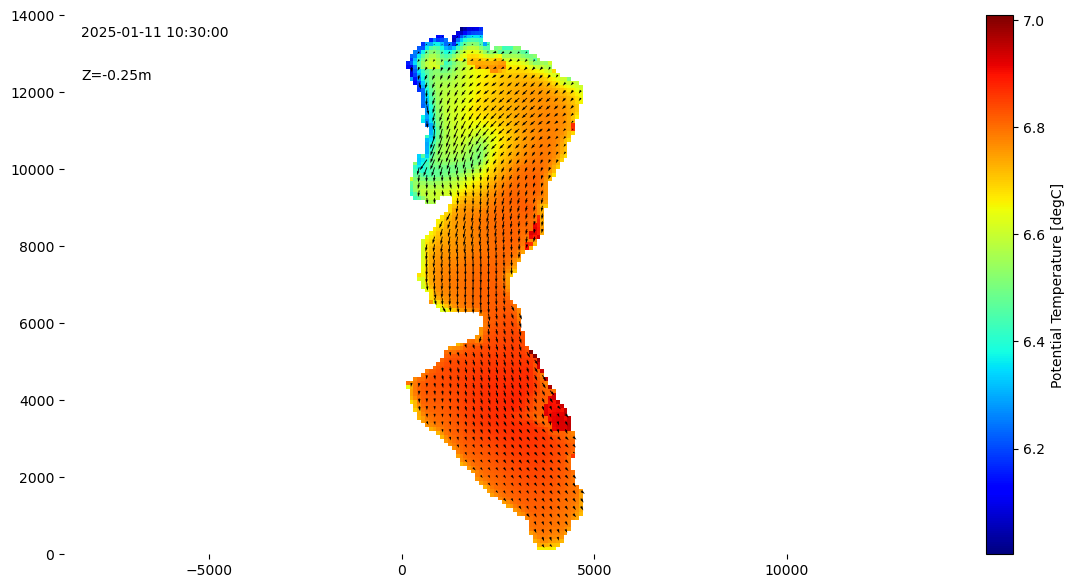

In [9]:
i_time = 250
i_depth = 0 #25
scale_arrow=7
subsetting_factor_arrow=2
vmin=None
vmax=None

plot_map(i_time, i_depth, scale_arrow, subsetting_factor_arrow, vmin, vmax)
#plt.xlim(5000, 10000)
plt.show()

In [10]:
map_folder_path = os.path.join(output_folder, "map_0m")
os.makedirs(map_folder_path, exist_ok=True)
for i in range(0, len(ds_to_plot.time),12):
    plt.close('all')
    plot_map(i, 0, scale_arrow, subsetting_factor_arrow, vmin, vmax)
    plt.savefig(os.path.join(map_folder_path, f"map_{i}.png"))

In [48]:
map_folder_path = os.path.join(output_folder, "snapshot_20250807")
os.makedirs(map_folder_path, exist_ok=True)
for i in range(0, 40,1):
    plt.close('all')
    plot_map(i_time, i, scale_arrow, subsetting_factor_arrow, vmin, vmax)
    plt.savefig(os.path.join(map_folder_path, f"map_{i}.png"))

In [13]:
map_folder_path = os.path.join(output_folder, "map_surface_august2025")
os.makedirs(map_folder_path, exist_ok=True)
for i in range(0, len(ds_to_plot.time)):
    plt.close('all')
    plot_map(i, i_depth, scale_arrow, subsetting_factor_arrow, vmin, vmax)
    plt.savefig(os.path.join(map_folder_path, f"map_{i}.png"))

# Streamlines

In [13]:
def plot_map_streamlines(i_time: int, i_depth: int, stream_density, vmin, vmax):
    plt.ioff()
    plt.close()
    fig, ax = plt.subplots(figsize=(20,7))

    T_plot = ds_to_plot['time'].values[i_time]
    Z_plot = ds_to_plot['Z'].values[i_depth]
    xr_plot = ds_to_plot['THETA'].sel(time=T_plot, Z=Z_plot)
    xr_plot = xr_plot.where(xr_plot != 0, np.nan)
    xr_plot.plot(cmap='jet', add_colorbar=False, vmin=vmin, vmax=vmax) #, vmin=vmin, vmax=vmax
    plt.axis('equal')

    xgrid, ygrid = np.meshgrid(ds_to_plot['XC'], ds_to_plot['YC'])
    plt.streamplot(xgrid, ygrid, ds_to_plot['UVEL'].sel(time=T_plot, Z=Z_plot), ds_to_plot['VVEL'].sel(time=T_plot, Z=Z_plot),
                   density=stream_density, color='black', linewidth=0.5,
                   arrowsize=0.7, arrowstyle='->')

    #plt.xlim(37500,42500)
    #plt.ylim(19500,24500)

    plt.text(0.2, 0.8, f'{np.datetime_as_string(T_plot, unit="s").replace("T", " ")}', transform=plt.gca().transAxes, ha='left', va='top')
    plt.text(0.2, 0.75, f'Z={int(Z_plot)}m', transform=plt.gca().transAxes, ha='left', va='top')
    plt.title('')

    # Remove axis, ticks, labels, and title
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    return plt.gcf()

In [14]:
np.arange(0,10,3)

array([0, 3, 6, 9])

In [15]:
idx = ds_to_plot.indexes['time'].get_indexer([datetime.datetime(2024,8,16)], method='nearest')[0]
print(idx)

0


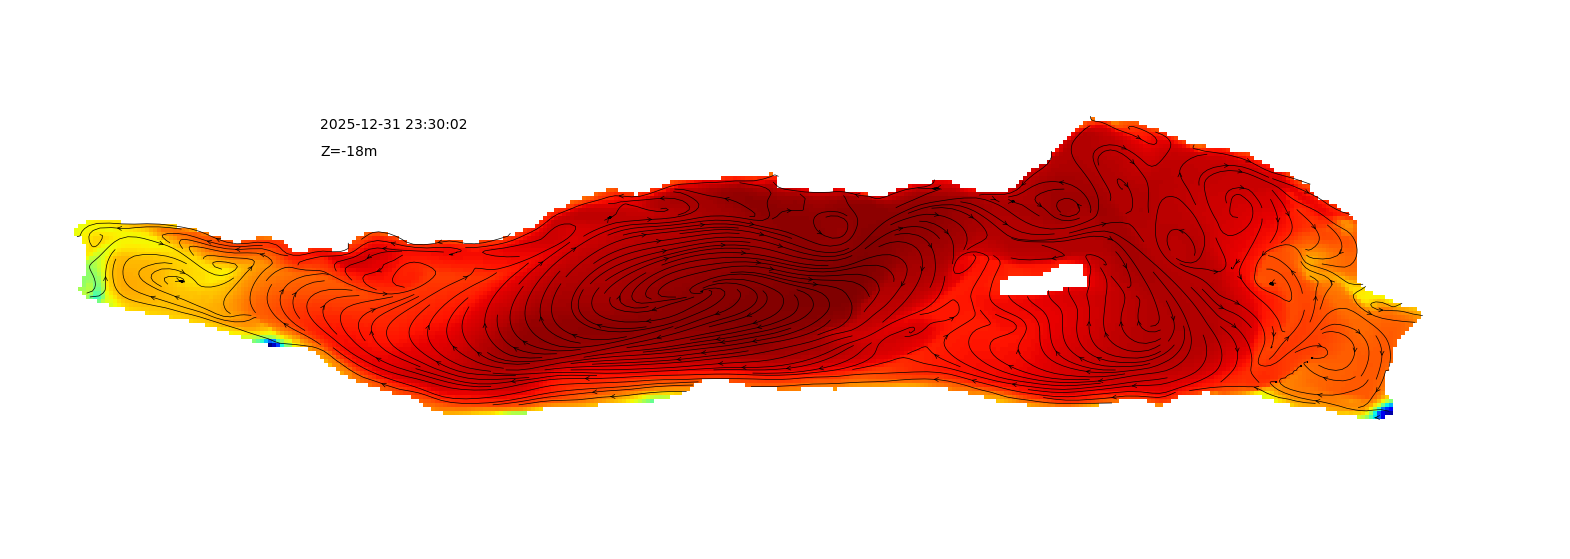

In [17]:
i_time = -1
i_depth = 25 #25
stream_density=4
vmin=None
vmax=None

plot_map_streamlines(i_time, i_depth, stream_density, vmin, vmax)

In [ ]:
i_time = idx
i_depth = 0 #25
stream_density=4
vmin=24
vmax=26

plot_map_streamlines(i_time, i_depth, stream_density, vmin, vmax)
plt.savefig(os.path.join(map_folder_path, f"map_{i_time}.png"), transparent=True)

In [ ]:
map_folder_path = os.path.join(output_folder, "map_streamlines_surface")
os.makedirs(map_folder_path, exist_ok=True)
for i in range(ds_to_plot.sizes['time']):
    plot_map_streamlines(i, i_depth, stream_density, vmin, vmax)
    plt.savefig(os.path.join(map_folder_path, f"map_{i}.png"), transparent=True)

# Transect

In [1]:
coords_transects = []

In [2]:
x1, y1 = 42000,9000
x2, y2 = 50000,20000
coords_transects.append([x1,y1,x2,y2])

In [3]:
x1, y1 = 34500,11500
x2, y2 = 41500,22500
coords_transects.append([x1,y1,x2,y2])

In [4]:
x1, y1 = 35000,20000
x2, y2 = 50000,11000
coords_transects.append([x1,y1,x2,y2])

In [13]:
i_depth = 25 #25
scale_arrow=4
subsetting_factor_arrow=10
vmin=None
vmax=None

plot_map(i_time, i_depth, scale_arrow, subsetting_factor_arrow, vmin, vmax)
for i_transect in range(len(coords_transects)):
    x1, y1, x2, y2 = coords_transects[i_transect]
    plt.plot([x1,x2], [y1,y2], c='red', marker='o', label='Transect')
plt.show()

NameError: name 'i_time' is not defined

In [110]:
npoints = 200  # resolution of transect

x_line = np.linspace(x1, x2, npoints)
y_line = np.linspace(y1, y2, npoints)
points = np.arange(npoints)

In [111]:
import xarray as xr

In [112]:
x_line = np.linspace(x1, x2, npoints)
y_line = np.linspace(y1, y2, npoints)

ds_stacked = ds_to_plot.stack(points=("YC","XC"))

x_da = xr.DataArray(x_line, dims="points")
y_da = xr.DataArray(y_line, dims="points")

transect = ds_to_plot["THETA"].sel(
    XC=x_da,
    YC=y_da,
    method="nearest"
)

dist = np.sqrt(np.diff(x_line)**2 + np.diff(y_line)**2)
dist = np.insert(np.cumsum(dist), 0, 0)

transect = transect.assign_coords(distance=("points", dist))

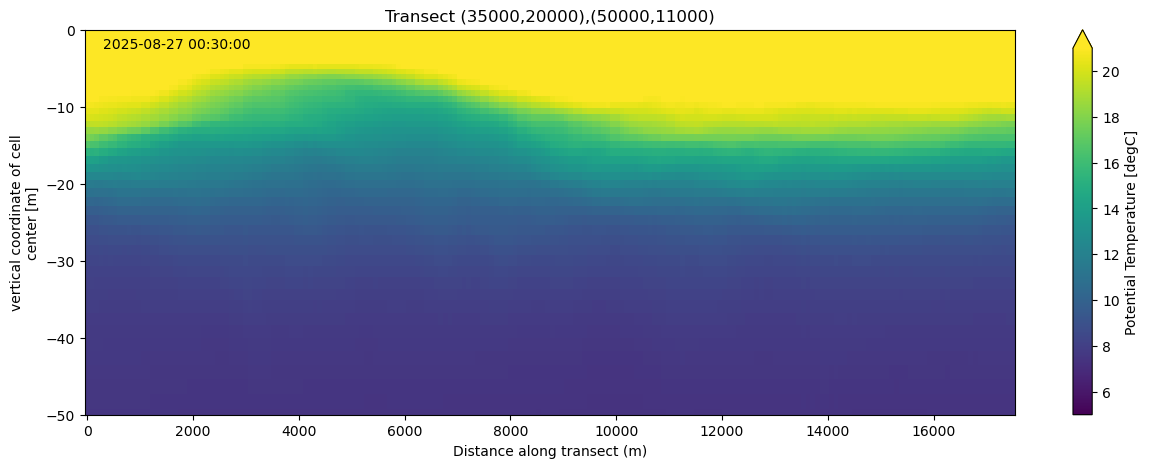

In [113]:
plt.figure(figsize=(15,5))
transect.isel(time=i_time).plot(
    x="distance",
    y="Z",
    vmin=5,vmax=21
)

plt.text(0.02, 0.98, f'{np.datetime_as_string(transect.isel(time=i_time).time.values, unit="s").replace("T", " ")}', transform=plt.gca().transAxes, ha='left', va='top')
plt.xlabel("Distance along transect (m)")
plt.ylim(-50,0)
plt.title(f"Transect ({x1},{y1}),({x2},{y2})")
plt.show()

In [114]:
transect_folder_path = os.path.join(output_folder, f"transect_[{x1},{y1}]_[{x2},{y2}]")
os.makedirs(transect_folder_path, exist_ok=True)
for i in range(5304, 5448):
    plt.close('all')
    plt.figure(figsize=(20,7))
    transect.isel(time=i).plot(
        x="distance",
        y="Z",
        vmin=5,vmax=21
    )
    plt.text(0.02, 0.98, f'{np.datetime_as_string(transect.isel(time=i).time.values, unit="s").replace("T", " ")}', transform=plt.gca().transAxes, ha='left', va='top')

    plt.xlabel("Distance along transect (m)")
    plt.ylim(-50,0)
    plt.title(f"Transect ({x1},{y1}),({x2},{y2})")
    plt.savefig(os.path.join(transect_folder_path, f"transect_{i}.png"))

In [ ]:
ds_to_plot['THETA'].sel(time=datetime.datetime(2024, 8, 3), method='nearest').sel(XC=1500, YC=2000, method='nearest').plot(y='Z')

plt.gca().set_ylim(bottom=-80, top=0)
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.ylabel('Depth (m)')
plt.xlabel('Temperature (°C)')
plt.show()

# Profile

In [23]:
x_sta = 20476.97561748123
y_sta = 4929.721502588825

ds_crop = ds_to_plot[['THETA','UVEL','VVEL']].sel(XC=x_sta, YC=y_sta, XG=x_sta, YG=y_sta, method='nearest')

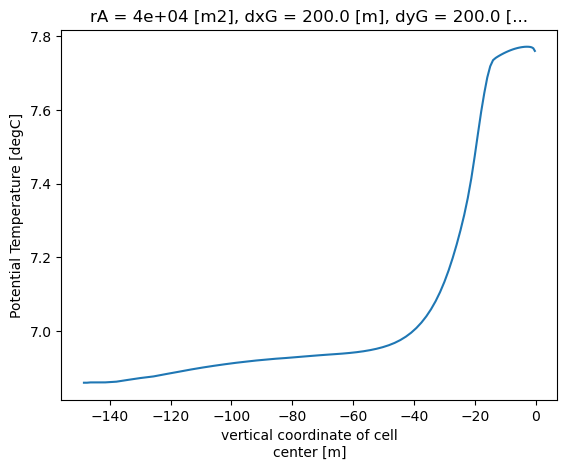

In [24]:
plt.close('all')
ds_crop.THETA.isel(time=1716).plot()
plt.show()

# Timeseries

In [9]:
import pandas as pd

In [11]:
coords = pd.read_csv("coordinates_transect_points_with_mitgcm_coords.csv")
coords.head()

,id,lat,lon,id_transec,x_mitgcm,y_mitgcm,col,row
0,NaN,46.991595,7.024213,1,37300.0,3500.0,186,17
1,NaN,46.989612,7.020898,1,36900.0,3500.0,184,17
2,NaN,46.987318,7.016730,1,36500.0,3500.0,182,17
3,NaN,46.984838,7.012519,1,36100.0,3500.0,180,17
4,NaN,46.982606,7.008622,1,35700.0,3500.0,178,17


In [30]:
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import numpy as np
from utils import (download_json)

In [34]:
coords

,id,lat,lon,id_transec,x_mitgcm,y_mitgcm,col,row
0,NaN,46.991595,7.024213,1,37300.0,3500.0,186,17
1,NaN,46.989612,7.020898,1,36900.0,3500.0,184,17
2,NaN,46.987318,7.016730,1,36500.0,3500.0,182,17
3,NaN,46.984838,7.012519,1,36100.0,3500.0,180,17
4,NaN,46.982606,7.008622,1,35700.0,3500.0,178,17
5,NaN,46.980219,7.004546,1,35300.0,3500.0,176,17
6,NaN,46.977801,7.000336,1,34900.0,3500.0,174,17
7,NaN,46.975599,6.996349,1,34500.0,3500.0,172,17
8,NaN,46.846907,6.832307,2,15700.0,700.0,78,3
9,NaN,46.849568,6.828776,2,15700.0,1100.0,78,5


In [37]:
dfs = []

for i, coord in coords.iterrows():
    url = fr"https://alplakes-api.eawag.ch/remotesensing/timeseries/neuchatel/collection/ST/{coord['lat']}/{coord['lon']}/20240101/20250101?window=2&valid_pixels=50"
    print(url)
    data = download_json(url)

    time_arr = []
    val_arr = []
    for pack in data:
        time_arr.append(pack["time"])
        val_arr.append(pack["value"]["mean"])

    time_dt = pd.to_datetime(time_arr, utc=True).tz_convert(None)

    df = pd.DataFrame(
        {
            "time": time_dt,
            "value": val_arr,
            "point": i,
            "transect_number": coord["id_transec"],
            "lat": coord["lat"],
            "lon": coord["lon"],
        }
    )

    dfs.append(df)


https://alplakes-api.eawag.ch/remotesensing/timeseries/neuchatel/collection/ST/46.991595/7.024213/20240101/20250101?window=2&valid_pixels=50
https://alplakes-api.eawag.ch/remotesensing/timeseries/neuchatel/collection/ST/46.989612/7.020898/20240101/20250101?window=2&valid_pixels=50
https://alplakes-api.eawag.ch/remotesensing/timeseries/neuchatel/collection/ST/46.987318/7.01673/20240101/20250101?window=2&valid_pixels=50
https://alplakes-api.eawag.ch/remotesensing/timeseries/neuchatel/collection/ST/46.984838/7.012519/20240101/20250101?window=2&valid_pixels=50
https://alplakes-api.eawag.ch/remotesensing/timeseries/neuchatel/collection/ST/46.982606/7.008622/20240101/20250101?window=2&valid_pixels=50
https://alplakes-api.eawag.ch/remotesensing/timeseries/neuchatel/collection/ST/46.980219/7.004546/20240101/20250101?window=2&valid_pixels=50
https://alplakes-api.eawag.ch/remotesensing/timeseries/neuchatel/collection/ST/46.977801/7.000336/20240101/20250101?window=2&valid_pixels=50
https://alplak

In [38]:
df_data = pd.concat(dfs)

In [41]:
df_data

,time,value,point,transect_number,lat,lon
0,2024-12-04 12:00:00,6.626590,0,1.0,46.991595,7.024213
1,2024-12-04 12:00:00,6.661044,0,1.0,46.991595,7.024213
2,2024-09-15 12:00:00,16.606525,0,1.0,46.991595,7.024213
3,2024-09-15 12:00:00,16.616507,0,1.0,46.991595,7.024213
4,2024-09-14 12:00:00,15.386049,0,1.0,46.991595,7.024213
...,...,...,...,...,...,...
21,2024-03-23 12:00:00,8.111925,27,3.0,46.979224,6.978098
22,2024-03-23 12:00:00,8.147882,27,3.0,46.979224,6.978098
23,2024-02-20 12:00:00,6.546471,27,3.0,46.979224,6.978098
24,2024-02-04 12:00:00,1.770404,27,3.0,46.979224,6.978098


In [ ]:
transect_number = 2
df_transect = coords[coords['id_transec']==transect_number]
nearshore_timeserie = ds_to_plot.THETA.isel(Z=0).sel(XC=df_transect['x_mitgcm'].iloc[0], YC=df_transect['y_mitgcm'].iloc[0], method='nearest')
offshore_timeserie = ds_to_plot.THETA.isel(Z=0).sel(XC=df_transect['x_mitgcm'].iloc[-1], YC=df_transect['y_mitgcm'].iloc[-1], method='nearest')
delta_T = nearshore_timeserie - offshore_timeserie
plt.figure(figsize=(7, 5))
plt.xticks(rotation=15, ha='right')
plt.hlines(0, delta_T.time.values[0], delta_T.time.values[-1], colors='black', linestyles='dashed')

#MITgcm
delta_T.plot(label="MITgcm", color='tab:red')

# Satellite
df_data_transect = df_data[df_data['transect_number']==transect_number]
times = np.sort(pd.unique(df_data_transect['time']))
sat_deltat_val = []
for t in times:
    df_snap = df_data_transect[df_data_transect['time']==t]
    sat_deltat_val.append(df_snap.iloc[0]['value'] - df_snap.iloc[-1]['value'])

plt.scatter(df_data_transect['time'], sat_deltat_val, label="Satellite", color='tab:blue', marker='x')

plt.title(rf"$\Delta$T offshore minus onshore - Transect {transect_number}")
plt.ylabel(r"$\Delta$T (°C)")

In [ ]:
# Satellite
df_data_transect = df_data[df_data['transect_number']==transect_number]
times = np.sort(pd.unique(df_data_transect['time']))
sat_deltat_val = []
for t in times:
    df_snap = df_data_transect[df_data_transect['time']==t]
    sat_deltat_val.append(df_snap.iloc[0]['value'] - df_snap.iloc[-1]['value'])

plt.scatter(df_data_transect['time'], sat_deltat_val, label="Satellite", color='tab:blue', marker='x')

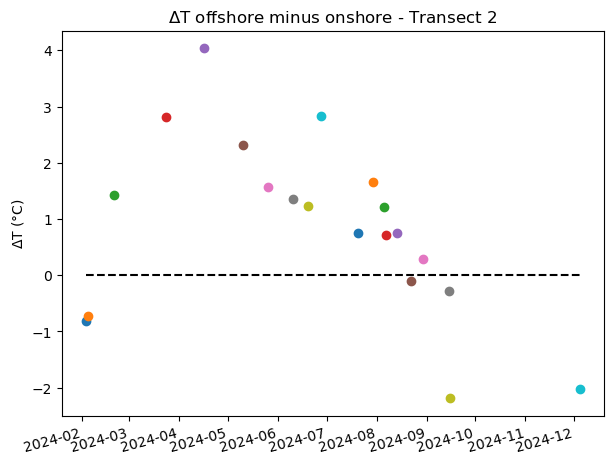

In [39]:
df_transect = df_data[df_data['transect_number']==transect_number]

plt.figure(figsize=(7, 5))
plt.title(rf"$\Delta$T offshore minus onshore - Transect {transect_number}")
plt.ylabel(r"$\Delta$T (°C)")
plt.xticks(rotation=15, ha='right')
plt.hlines(0, times[0], times[-1], colors='black', linestyles='dashed')
